# EEG α波和β波时间变化分析：三种情绪状态对比
# EEG Alpha and Beta Wave Time-Series Analysis: Comparison of Three Emotional States

## 教学目标

通过本模块，你将能够：
1. **观察α波（8-13 Hz）随时间的变化**，理解其与放松状态的关系
2. **观察β波（13-30 Hz）随时间的变化**，理解其与警觉/紧张状态的关系
3. 掌握使用滑动窗口计算频段能量时间序列的方法
4. 学会对比不同情绪状态下α波和β波的动态变化特征
5. 为音乐干预实验的波形对比分析打下基础

---

## 实验设计

我们将分析三个测试数据集，分别代表三种不同的情绪状态：

| 情绪状态 | 数据文件 | 场景描述 | 预期特征 |
|---------|---------|----------|----------|
| **Alert（警觉/专注）** | `Quietly_work.csv` | 安静工作状态，需要集中注意力 | β波较高，α波适中 |
| **Relaxed（放松）** | `Daily_communication.csv` | 日常交流状态，轻松自然 | α波较高，β波较低 |
| **Nervous（紧张）** | `Stressful_communication.csv` | 压力交流状态，紧张焦虑 | β波高，α波低 |

### 分析流程

```
原始数据 → 预处理 → 滑动窗口频段能量计算 → 时间序列可视化 → 观察α/β波变化规律
```

1. **数据读取**：加载三个CSV文件的EEG数据（16通道）
2. **信号预处理**：带通滤波（0.5-40Hz）+ Z-score标准化
3. **时间序列计算**：使用滑动窗口计算α波和β波能量随时间变化
   - **α波 (Alpha)**: 8-13 Hz - 与放松、安静清醒状态相关
   - **β波 (Beta)**: 13-30 Hz - 与警觉、专注、紧张状态相关
4. **可视化**：绘制α波和β波随时间变化的曲线图
5. **对比分析**：观察三种情绪状态的α/β波动态差异

### 核心指标

- **α波增强** → 表示放松、平静
- **β波下降** → 表示压力减轻、紧张缓解
- **α/β比率** → 比率越高，越放松；比率越低，越警觉/紧张

---

## 1. 导入必要的库

In [71]:
# ============================================================================
# 导入必要的Python库
# ============================================================================

# NumPy: 用于数值计算和数组操作，是科学计算的基础库
import numpy as np

# Pandas: 用于数据读取和处理，特别适合处理CSV等表格数据
import pandas as pd

# Matplotlib: 用于数据可视化，绘制各种图表
import matplotlib.pyplot as plt

# SciPy的signal模块: 提供信号处理工具，如滤波、FFT、Welch方法等
from scipy import signal

# OS模块: 用于文件和路径操作，如检查文件是否存在
import os

# ============================================================================
# 配置Matplotlib的显示参数
# ============================================================================

# 设置中文字体，避免中文显示为方框乱码
# 按优先级尝试：微软雅黑 > 黑体 > Arial Unicode MS
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']

# 解决负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 设置图形分辨率（DPI），100是适合屏幕显示的数值
plt.rcParams['figure.dpi'] = 100

# ============================================================================
# 打印导入成功信息
# ============================================================================
print("✓ 库导入成功！")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ 库导入成功！
NumPy version: 2.1.2
Pandas version: 2.2.3


## 2. 定义数据预处理和分析函数

### 2.1 数据加载函数

首先定义一个函数来加载EEG数据（16通道）。

In [72]:
def load_eeg_data(csv_file):
    """
    加载EEG数据（16通道）
    
    这个函数负责从CSV文件中读取EEG数据，并进行基本的验证和信息输出。
    
    参数:
        csv_file: CSV文件的完整路径（字符串）
    
    返回:
        eeg_data: numpy数组，形状为(时间点数, 16通道)
    
    异常:
        如果文件不存在，会抛出FileNotFoundError异常
    """
    # ------------------------------------------------------------------------
    # 检查文件是否存在
    # ------------------------------------------------------------------------
    if not os.path.exists(csv_file):
        # 如果文件不存在，抛出异常并停止执行
        raise FileNotFoundError(f"文件不存在: {csv_file}")
    
    # ------------------------------------------------------------------------
    # 读取CSV文件
    # ------------------------------------------------------------------------
    # skiprows=1: 跳过第一行（标题行，如"Time,CH0,CH1,..."）
    # usecols=range(1, 17): 只读取第2-17列（索引1-16），共16个EEG通道
    #                       第1列（索引0）是时间戳，这里不需要
    df = pd.read_csv(csv_file, skiprows=1, usecols=range(1, 17))
    
    # 将Pandas DataFrame转换为NumPy数组
    # 形状为：(时间点数, 16个通道)
    eeg_data = df.values
    
    # ------------------------------------------------------------------------
    # 打印数据加载信息
    # ------------------------------------------------------------------------
    print(f"  ✓ 数据加载成功: {os.path.basename(csv_file)}")  # 只显示文件名，不显示完整路径
    print(f"    形状: {eeg_data.shape} (时间点数={eeg_data.shape[0]}, 通道数={eeg_data.shape[1]})")
    
    # 计算并显示数据时长（秒）
    # 采样率为202Hz，所以时长 = 时间点数 / 202
    print(f"    时长: {eeg_data.shape[0]/202:.2f} 秒")
    
    return eeg_data

# ============================================================================
# 函数定义完成提示
# ============================================================================
print("✓ 数据加载函数定义完成")

✓ 数据加载函数定义完成


### 2.2 EEG数据预处理函数

对原始EEG数据进行带通滤波和Z-score标准化，去除噪声和基线漂移。

In [73]:
def preprocess_eeg(eeg_data, sampling_rate=202, lowcut=0.5, highcut=40):
    """
    预处理EEG数据：带通滤波 + Z-score标准化
    
    这个函数执行两个关键的预处理步骤：
    1. 带通滤波：去除基线漂移和高频噪声
    2. Z-score标准化：消除通道间的幅度差异
    
    参数:
        eeg_data: 原始EEG数据，形状为(时间点数, 通道数)
        sampling_rate: 采样率(Hz)，默认202Hz
        lowcut: 低频截止频率(Hz)，默认0.5Hz
        highcut: 高频截止频率(Hz)，默认40Hz
    
    返回:
        filtered_data: 预处理后的数据，形状与输入相同
    """
    # ========================================================================
    # 步骤1: 带通滤波（Bandpass Filter）
    # ========================================================================
    # 目的：保留0.5-40Hz的频率成分，去除极低频漂移和高频噪声
    
    # 计算奈奎斯特频率（采样率的一半）
    nyquist = sampling_rate / 2.0
    
    # 将截止频率归一化到[0, 1]范围
    low = lowcut / nyquist     # 低频截止归一化
    high = highcut / nyquist   # 高频截止归一化
    
    # 设计4阶巴特沃斯带通滤波器
    # 返回滤波器系数b（分子）和a（分母）
    b, a = signal.butter(4, [low, high], btype='band')
    
    # 应用零相位滤波（前向-后向滤波）
    # axis=0: 沿着时间维度（第0维）进行滤波
    filtered_data = signal.filtfilt(b, a, eeg_data, axis=0)
    
    # ========================================================================
    # 步骤2: Z-score标准化（Standardization）
    # ========================================================================
    # 目的：使不同通道的数据具有可比性（均值=0，标准差=1）
    
    # 计算每个通道的均值
    # axis=0: 沿着时间维度计算，得到每个通道的均值
    # keepdims=True: 保持维度，便于后续的广播运算
    mean = np.mean(filtered_data, axis=0, keepdims=True)
    
    # 计算每个通道的标准差
    std = np.std(filtered_data, axis=0, keepdims=True)
    
    # 应用Z-score标准化公式：z = (x - mean) / std
    # 加上1e-8避免除以0（当标准差接近0时）
    filtered_data = (filtered_data - mean) / (std + 1e-8)
    
    return filtered_data

# ============================================================================
# 函数定义完成提示
# ============================================================================
print("✓ 预处理函数定义完成")

✓ 预处理函数定义完成


### 2.3 计算频段能量时间序列函数

使用滑动窗口方法计算α波和β波能量随时间的变化。

**核心思想**：
- 将整个信号分成多个重叠的时间窗口
- 对每个窗口计算α波和β波的能量
- 得到能量随时间变化的曲线

In [74]:
def calculate_band_power_timeseries(eeg_data, sampling_rate=202, 
                                    band_range=(8, 13), 
                                    window_size=4, 
                                    overlap=0.75,
                                    channels='all'):
    """
    计算指定频段能量随时间的变化
    
    这个函数使用滑动窗口方法计算EEG信号在特定频段（如α波、β波）的能量
    随时间的动态变化，用于观察情绪状态的时间演变。
    
    参数:
        eeg_data: 预处理后的EEG数据，形状为(时间点数, 通道数)
        sampling_rate: 采样率(Hz)，默认202Hz
        band_range: 频段范围（元组），例如：
                   - (8, 13)  表示α波
                   - (13, 30) 表示β波
        window_size: 滑动窗口大小(秒)，默认4秒
                    更大的窗口可以提高频率分辨率，但会降低时间分辨率
        overlap: 窗口重叠比例 (0-1)，默认0.75
                0.75表示相邻窗口有75%的重叠，可以得到更平滑的时间序列
        channels: 要分析的通道，支持三种格式：
                 - 'all': 使用所有16个通道的平均值
                 - 整数: 使用单个通道，例如 0 表示Channel 0
                 - 列表: 使用多个通道的平均，例如 [0, 1, 2]
    
    返回:
        time_points: 时间点数组(秒)，每个值对应一个窗口的中心时刻
        power_timeseries: 对应时间点的频段能量（功率谱密度的平均值）
    """
    # ========================================================================
    # 步骤1: 选择要分析的通道
    # ========================================================================
    
    if channels == 'all':
        # 使用所有16个通道的平均值
        # axis=1表示沿着通道维度（第1维）计算平均
        # 结果是一维数组，长度为时间点数
        data_to_analyze = np.mean(eeg_data, axis=1)
        
    elif isinstance(channels, int):
        # 使用单个通道的数据
        # eeg_data[:, channels]提取指定通道的所有时间点
        data_to_analyze = eeg_data[:, channels]
        
    elif isinstance(channels, list):
        # 使用多个通道的平均值
        # eeg_data[:, channels]提取指定通道，然后计算平均
        data_to_analyze = np.mean(eeg_data[:, channels], axis=1)
        
    else:
        # 如果channels参数格式不正确，抛出异常
        raise ValueError("channels参数必须是'all'、整数或列表")
    
    # ========================================================================
    # 步骤2: 计算滑动窗口参数
    # ========================================================================
    
    # 窗口大小（采样点数）
    # 例如：4秒 × 202Hz = 808个采样点
    window_samples = int(window_size * sampling_rate)
    
    # 窗口移动步长（采样点数）
    # 例如：overlap=0.75，则步长 = 808 × (1-0.75) = 202个点
    # 即每次移动1秒，窗口之间有75%的重叠
    step_samples = int(window_samples * (1 - overlap))
    
    # ========================================================================
    # 步骤3: 使用滑动窗口计算频段能量时间序列
    # ========================================================================
    
    # 存储时间点和对应的频段能量
    time_points = []
    power_timeseries = []
    
    # 遍历所有可能的窗口位置
    # range的步长为step_samples，确保窗口之间有指定的重叠
    for start in range(0, len(data_to_analyze) - window_samples, step_samples):
        # 计算当前窗口的结束位置
        end = start + window_samples
        
        # 提取当前窗口的数据
        window_data = data_to_analyze[start:end]
        
        # --------------------------------------------------------------------
        # 计算该窗口的功率谱密度（使用Welch方法）
        # --------------------------------------------------------------------
        # nperseg: 每段的长度，使用min(256, window_samples)确保不超过窗口大小
        freqs, power = signal.welch(
            window_data, 
            fs=sampling_rate, 
            nperseg=min(256, window_samples)
        )
        
        # --------------------------------------------------------------------
        # 提取指定频段的能量
        # --------------------------------------------------------------------
        # 创建布尔索引，标记哪些频率点在指定频段内
        idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
        
        # 计算该频段内所有频率点的平均功率，作为该窗口的频段能量
        band_power = np.mean(power[idx_band])
        
        # --------------------------------------------------------------------
        # 记录时间点（窗口的中心时刻）
        # --------------------------------------------------------------------
        # 窗口中心时刻 = (起始位置 + 结束位置) / 2 / 采样率
        time_point = (start + end) / 2 / sampling_rate
        
        # 添加到结果列表
        time_points.append(time_point)
        power_timeseries.append(band_power)
    
    # ========================================================================
    # 步骤4: 返回结果（转换为NumPy数组）
    # ========================================================================
    return np.array(time_points), np.array(power_timeseries)

# ============================================================================
# 函数定义完成提示
# ============================================================================
print("✓ 时间序列计算函数定义完成")

✓ 时间序列计算函数定义完成


## 3. 加载并分析三种情绪状态的数据

现在我们对三个数据集分别进行分析，计算它们的α波和β波随时间变化的曲线。

**分析步骤：**
1. 加载数据
2. 预处理（滤波+标准化）
3. 计算α波时间序列
4. 计算β波时间序列

In [75]:
# ============================================================================
# 定义数据文件路径和分析参数
# ============================================================================

# ----------------------------------------------------------------------------
# 数据文件映射表
# ----------------------------------------------------------------------------
# 将三种情绪状态映射到对应的CSV文件路径
data_files = {
    'Alert': './dataset/test/Quietly_work.csv',       # 安静工作状态
    'Relaxed': './dataset/test/Daily_communication.csv',    # 日常交流状态
    'Nervous': './dataset/train/Nervous/CurveData_11_Badly_for_translation.csv' # 压力交流状态
}

# ----------------------------------------------------------------------------
# 分析参数设置（全局常量）
# ----------------------------------------------------------------------------
SAMPLING_RATE = 202  # 采样率(Hz)：每秒采集202个数据点
WINDOW_SIZE = 4      # 滑动窗口大小(秒)：每个窗口包含4秒的数据
OVERLAP = 0.75       # 窗口重叠比例：75%重叠，即相邻窗口有3秒重叠
CHANNELS = 'all'     # 通道选择：使用所有16个通道的平均值

# ----------------------------------------------------------------------------
# 创建结果存储字典
# ----------------------------------------------------------------------------
# 用于存储三种情绪状态的所有分析结果
all_results = {}

# ============================================================================
# 开始批量分析三种情绪状态的数据
# ============================================================================
print("="*70)
print("开始分析三种情绪状态的α波和β波时间变化")
print("="*70)

# ----------------------------------------------------------------------------
# 遍历所有数据文件，逐个进行分析
# ----------------------------------------------------------------------------
for state_name, filepath in data_files.items():
    # 检查文件是否存在
    if not os.path.exists(filepath):
        print(f"\n警告: 文件不存在 - {filepath}")
        continue  # 跳过不存在的文件，继续处理下一个
    
    # 打印当前处理的情绪状态
    print(f"\n【{state_name}】")
    
    # ------------------------------------------------------------------------
    # 步骤1: 加载EEG数据
    # ------------------------------------------------------------------------
    eeg_data = load_eeg_data(filepath)
    
    # ------------------------------------------------------------------------
    # 步骤2: 预处理（带通滤波 + Z-score标准化）
    # ------------------------------------------------------------------------
    print("  ✓ 预处理中...")
    filtered_data = preprocess_eeg(eeg_data, SAMPLING_RATE)
    
    # ------------------------------------------------------------------------
    # 步骤3: 计算α波（8-13 Hz）能量时间序列
    # ------------------------------------------------------------------------
    print("  ✓ 计算α波(8-13 Hz)能量变化...")
    time_alpha, power_alpha = calculate_band_power_timeseries(
        filtered_data,                # 输入：预处理后的数据
        sampling_rate=SAMPLING_RATE,  # 采样率：202Hz
        band_range=(8, 13),           # α波频段：8-13Hz
        window_size=WINDOW_SIZE,      # 窗口大小：4秒
        overlap=OVERLAP,              # 窗口重叠：75%
        channels=CHANNELS             # 使用所有通道的平均
    )
    
    # ------------------------------------------------------------------------
    # 步骤4: 计算β波（13-30 Hz）能量时间序列
    # ------------------------------------------------------------------------
    print("  ✓ 计算β波(13-30 Hz)能量变化...")
    time_beta, power_beta = calculate_band_power_timeseries(
        filtered_data,                # 输入：预处理后的数据
        sampling_rate=SAMPLING_RATE,  # 采样率：202Hz
        band_range=(13, 30),          # β波频段：13-30Hz
        window_size=WINDOW_SIZE,      # 窗口大小：4秒
        overlap=OVERLAP,              # 窗口重叠：75%
        channels=CHANNELS             # 使用所有通道的平均
    )
    
    # ------------------------------------------------------------------------
    # 步骤5: 计算统计指标并存储结果
    # ------------------------------------------------------------------------
    all_results[state_name] = {
        # 时间序列数据
        'time_alpha': time_alpha,           # α波的时间点数组
        'power_alpha': power_alpha,         # α波的能量时间序列
        'time_beta': time_beta,             # β波的时间点数组
        'power_beta': power_beta,           # β波的能量时间序列
        
        # 统计指标
        'alpha_mean': np.mean(power_alpha), # α波平均能量
        'beta_mean': np.mean(power_beta),   # β波平均能量
        'alpha_std': np.std(power_alpha),   # α波能量的标准差
        'beta_std': np.std(power_beta),     # β波能量的标准差
        
        # α/β比率（重要的情绪指标）
        # 比率越高表示越放松，比率越低表示越警觉/紧张
        'alpha_beta_ratio': np.mean(power_alpha) / np.mean(power_beta)
    }
    
    # ------------------------------------------------------------------------
    # 步骤6: 打印该状态的统计信息
    # ------------------------------------------------------------------------
    print(f"  → α波平均能量: {np.mean(power_alpha):.6f} (标准差: {np.std(power_alpha):.6f})")
    print(f"  → β波平均能量: {np.mean(power_beta):.6f} (标准差: {np.std(power_beta):.6f})")
    print(f"  → α/β比率: {np.mean(power_alpha)/np.mean(power_beta):.4f}")

# ============================================================================
# 所有数据分析完成
# ============================================================================
print("\n" + "="*70)
print("✓ 所有数据分析完成！")
print("="*70)

开始分析三种情绪状态的α波和β波时间变化

【Alert】
  ✓ 数据加载成功: Quietly_work.csv
    形状: (23004, 16) (时间点数=23004, 通道数=16)
    时长: 113.88 秒
  ✓ 预处理中...
  ✓ 计算α波(8-13 Hz)能量变化...
  ✓ 计算β波(13-30 Hz)能量变化...
  → α波平均能量: 0.003927 (标准差: 0.003347)
  → β波平均能量: 0.006084 (标准差: 0.009105)
  → α/β比率: 0.6454

【Relaxed】
  ✓ 数据加载成功: Daily_communication.csv
    形状: (64106, 16) (时间点数=64106, 通道数=16)
    时长: 317.36 秒
  ✓ 预处理中...
  ✓ 计算α波(8-13 Hz)能量变化...
  ✓ 计算β波(13-30 Hz)能量变化...
  → α波平均能量: 0.003882 (标准差: 0.001580)
  → β波平均能量: 0.004261 (标准差: 0.002097)
  → α/β比率: 0.9111

【Nervous】
  ✓ 数据加载成功: CurveData_11_Badly_for_translation.csv
    形状: (55154, 16) (时间点数=55154, 通道数=16)
    时长: 273.04 秒
  ✓ 预处理中...
  ✓ 计算α波(8-13 Hz)能量变化...
  ✓ 计算β波(13-30 Hz)能量变化...
  → α波平均能量: 0.003559 (标准差: 0.003579)
  → β波平均能量: 0.003333 (标准差: 0.002518)
  → α/β比率: 1.0679

✓ 所有数据分析完成！


## 4. 可视化：α波和β波随时间变化的对比

### 4.1 绘制单个状态的α波和β波时间变化

首先，我们为每个情绪状态分别绘制α波和β波随时间的变化曲线。

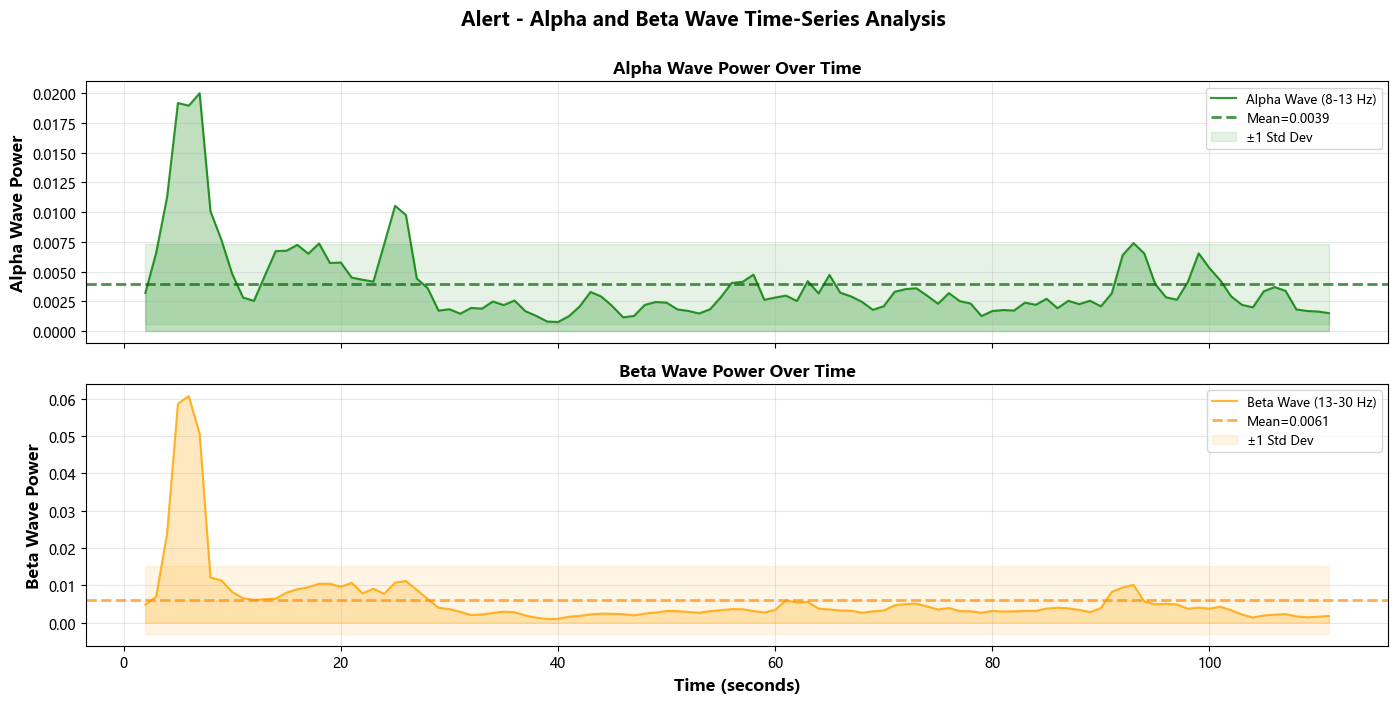


Alert 分析结果:
  α波: 平均=0.003927, 标准差=0.003347
  β波: 平均=0.006084, 标准差=0.009105
  α/β比率: 0.6454
------------------------------------------------------------


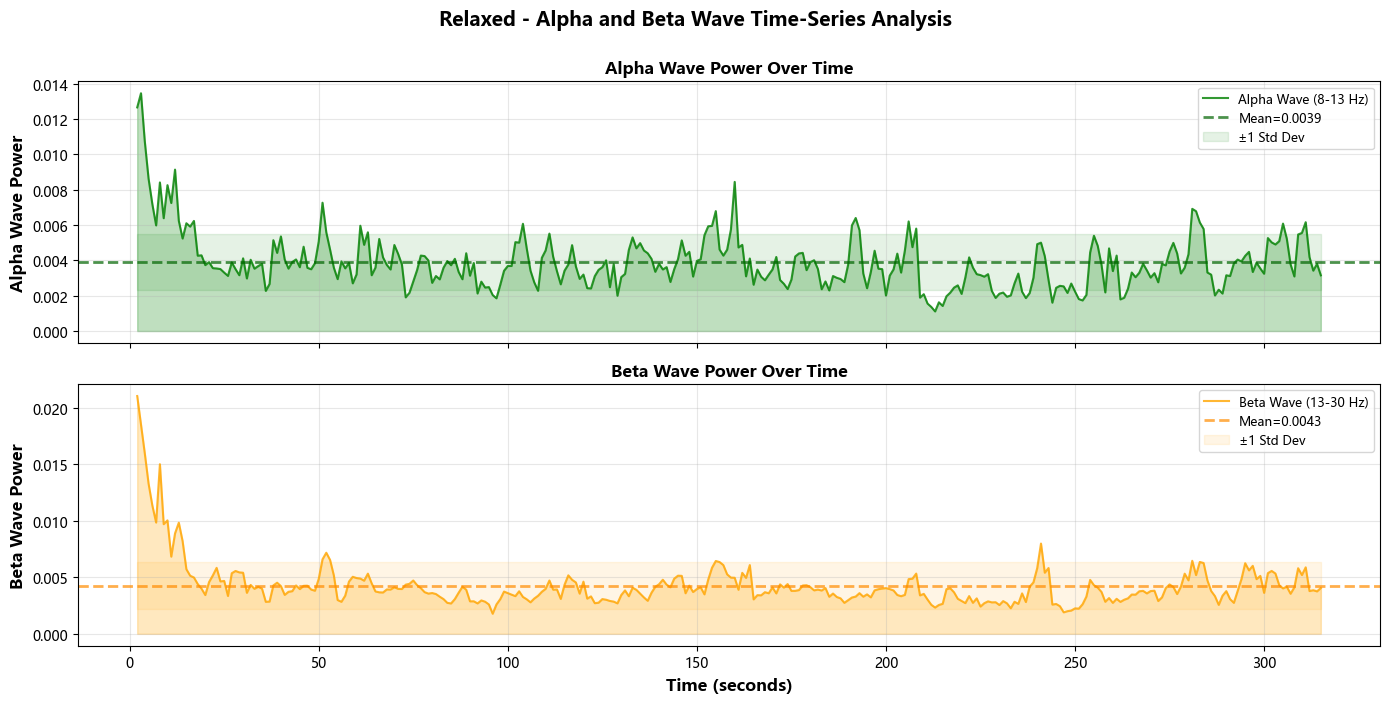


Relaxed 分析结果:
  α波: 平均=0.003882, 标准差=0.001580
  β波: 平均=0.004261, 标准差=0.002097
  α/β比率: 0.9111
------------------------------------------------------------


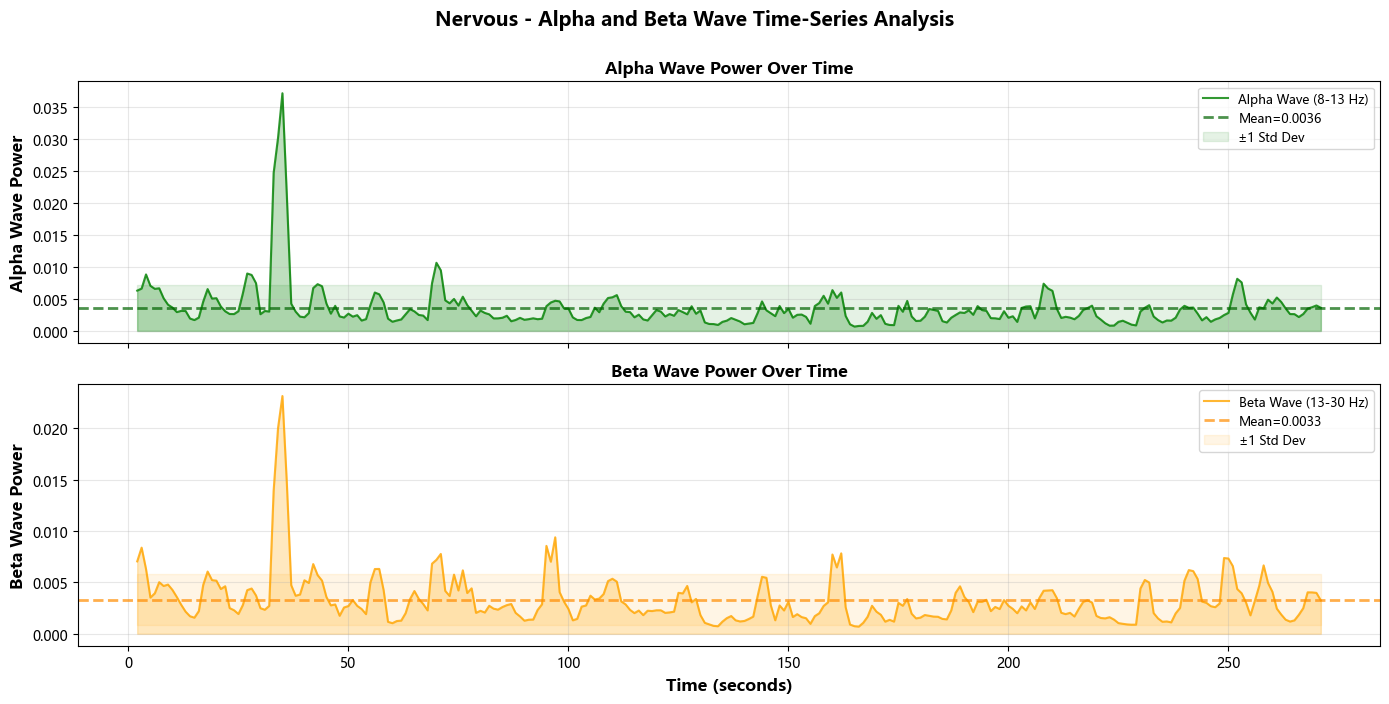


Nervous 分析结果:
  α波: 平均=0.003559, 标准差=0.003579
  β波: 平均=0.003333, 标准差=0.002518
  α/β比率: 1.0679
------------------------------------------------------------


In [76]:
# ============================================================================
# 为每个情绪状态绘制α波和β波时间变化图
# ============================================================================

# 遍历所有情绪状态的分析结果
for state_name, result in all_results.items():
    # ------------------------------------------------------------------------
    # 创建2行1列的子图布局，两个子图共享X轴
    # ------------------------------------------------------------------------
    # subplots(2, 1): 2行1列的布局，上图显示α波，下图显示β波
    # sharex=True: 两个子图共享X轴（时间轴），便于对比同一时刻的α波和β波
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    
    # ------------------------------------------------------------------------
    # 从结果字典中提取数据
    # ------------------------------------------------------------------------
    time_alpha = result['time_alpha']      # α波的时间点数组
    power_alpha = result['power_alpha']    # α波的能量时间序列
    time_beta = result['time_beta']        # β波的时间点数组
    power_beta = result['power_beta']      # β波的能量时间序列
    alpha_mean = result['alpha_mean']      # α波的平均能量
    alpha_std = result['alpha_std']        # α波能量的标准差
    beta_mean = result['beta_mean']        # β波的平均能量
    beta_std = result['beta_std']          # β波能量的标准差
    
    # ========================================================================
    # 上图：α波能量随时间变化
    # ========================================================================
    
    # 绘制α波能量曲线
    ax1.plot(
        time_alpha,           # X轴：时间（秒）
        power_alpha,          # Y轴：α波能量
        'g-',                 # 绿色实线
        linewidth=1.5,        # 线条宽度
        label='Alpha Wave (8-13 Hz)', # 图例标签
        alpha=0.8             # 透明度80%
    )
    
    # 在曲线下方填充浅绿色，使曲线更醒目
    ax1.fill_between(
        time_alpha,           # X轴范围
        power_alpha,          # 从Y=power_alpha到Y=0的区域
        alpha=0.25,           # 透明度25%
        color='green'         # 填充颜色
    )
    
    # 绘制平均值参考线（深绿色虚线）
    ax1.axhline(
        y=alpha_mean,                        # 水平线的Y坐标值
        color='darkgreen',                   # 深绿色
        linestyle='--',                      # 虚线
        linewidth=2,                         # 线条宽度
        alpha=0.7,                           # 透明度70%
        label=f'Mean={alpha_mean:.4f}'     # 图例标签
    )
    
    # 绘制±1标准差范围（浅绿色阴影）
    ax1.fill_between(
        time_alpha,                          # X轴范围
        alpha_mean - alpha_std,              # 下限：均值 - 1标准差
        alpha_mean + alpha_std,              # 上限：均值 + 1标准差
        color='green',                       # 填充颜色
        alpha=0.1,                           # 透明度10%
        label='±1 Std Dev'                    # 图例标签
    )
    
    # 设置Y轴标签
    ax1.set_ylabel('Alpha Wave Power', fontsize=12, fontweight='bold')
    
    # 设置子图标题
    ax1.set_title('Alpha Wave Power Over Time', fontsize=12, fontweight='bold')
    
    # 显示网格
    ax1.grid(True, alpha=0.3)
    
    # 显示图例（位于右上角）
    ax1.legend(loc='upper right', fontsize=9)
    
    # ========================================================================
    # 下图：β波能量随时间变化
    # ========================================================================
    
    # 绘制β波能量曲线
    ax2.plot(
        time_beta,            # X轴：时间（秒）
        power_beta,           # Y轴：β波能量
        'orange',             # 橙色实线
        linewidth=1.5,        # 线条宽度
        label='Beta Wave (13-30 Hz)', # 图例标签
        alpha=0.8             # 透明度80%
    )
    
    # 在曲线下方填充浅橙色
    ax2.fill_between(
        time_beta,            # X轴范围
        power_beta,           # 从Y=power_beta到Y=0的区域
        alpha=0.25,           # 透明度25%
        color='orange'        # 填充颜色
    )
    
    # 绘制平均值参考线（深橙色虚线）
    ax2.axhline(
        y=beta_mean,                         # 水平线的Y坐标值
        color='darkorange',                  # 深橙色
        linestyle='--',                      # 虚线
        linewidth=2,                         # 线条宽度
        alpha=0.7,                           # 透明度70%
        label=f'Mean={beta_mean:.4f}'      # 图例标签
    )
    
    # 绘制±1标准差范围（浅橙色阴影）
    ax2.fill_between(
        time_beta,                           # X轴范围
        beta_mean - beta_std,                # 下限：均值 - 1标准差
        beta_mean + beta_std,                # 上限：均值 + 1标准差
        color='orange',                      # 填充颜色
        alpha=0.1,                           # 透明度10%
        label='±1 Std Dev'                    # 图例标签
    )
    
    # 设置X轴标签（只在下图显示，因为两个子图共享X轴）
    ax2.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    
    # 设置Y轴标签
    ax2.set_ylabel('Beta Wave Power', fontsize=12, fontweight='bold')
    
    # 设置子图标题
    ax2.set_title('Beta Wave Power Over Time', fontsize=12, fontweight='bold')
    
    # 显示网格
    ax2.grid(True, alpha=0.3)
    
    # 显示图例（位于右上角）
    ax2.legend(loc='upper right', fontsize=9)
    
    # ------------------------------------------------------------------------
    # 设置整个图形的总标题
    # ------------------------------------------------------------------------
    plt.suptitle(
        f'{state_name} - Alpha and Beta Wave Time-Series Analysis',  # 总标题内容
        fontsize=14,                            # 字体大小
        fontweight='bold',                      # 粗体
        y=1.00                                  # Y位置（调整避免与子图重叠）
    )
    
    # 自动调整布局
    plt.tight_layout()
    
    # 显示图形
    plt.show()
    
    # ------------------------------------------------------------------------
    # 打印该状态的文字总结
    # ------------------------------------------------------------------------
    print(f"\n{state_name} 分析结果:")
    print(f"  α波: 平均={alpha_mean:.6f}, 标准差={alpha_std:.6f}")
    print(f"  β波: 平均={beta_mean:.6f}, 标准差={beta_std:.6f}")
    print(f"  α/β比率: {result['alpha_beta_ratio']:.4f}")
    print("-" * 60)

### 4.2 三种情绪状态的α波和β波对比

将三种情绪状态的α波和β波放在一起对比，观察不同情绪状态下的波形差异。

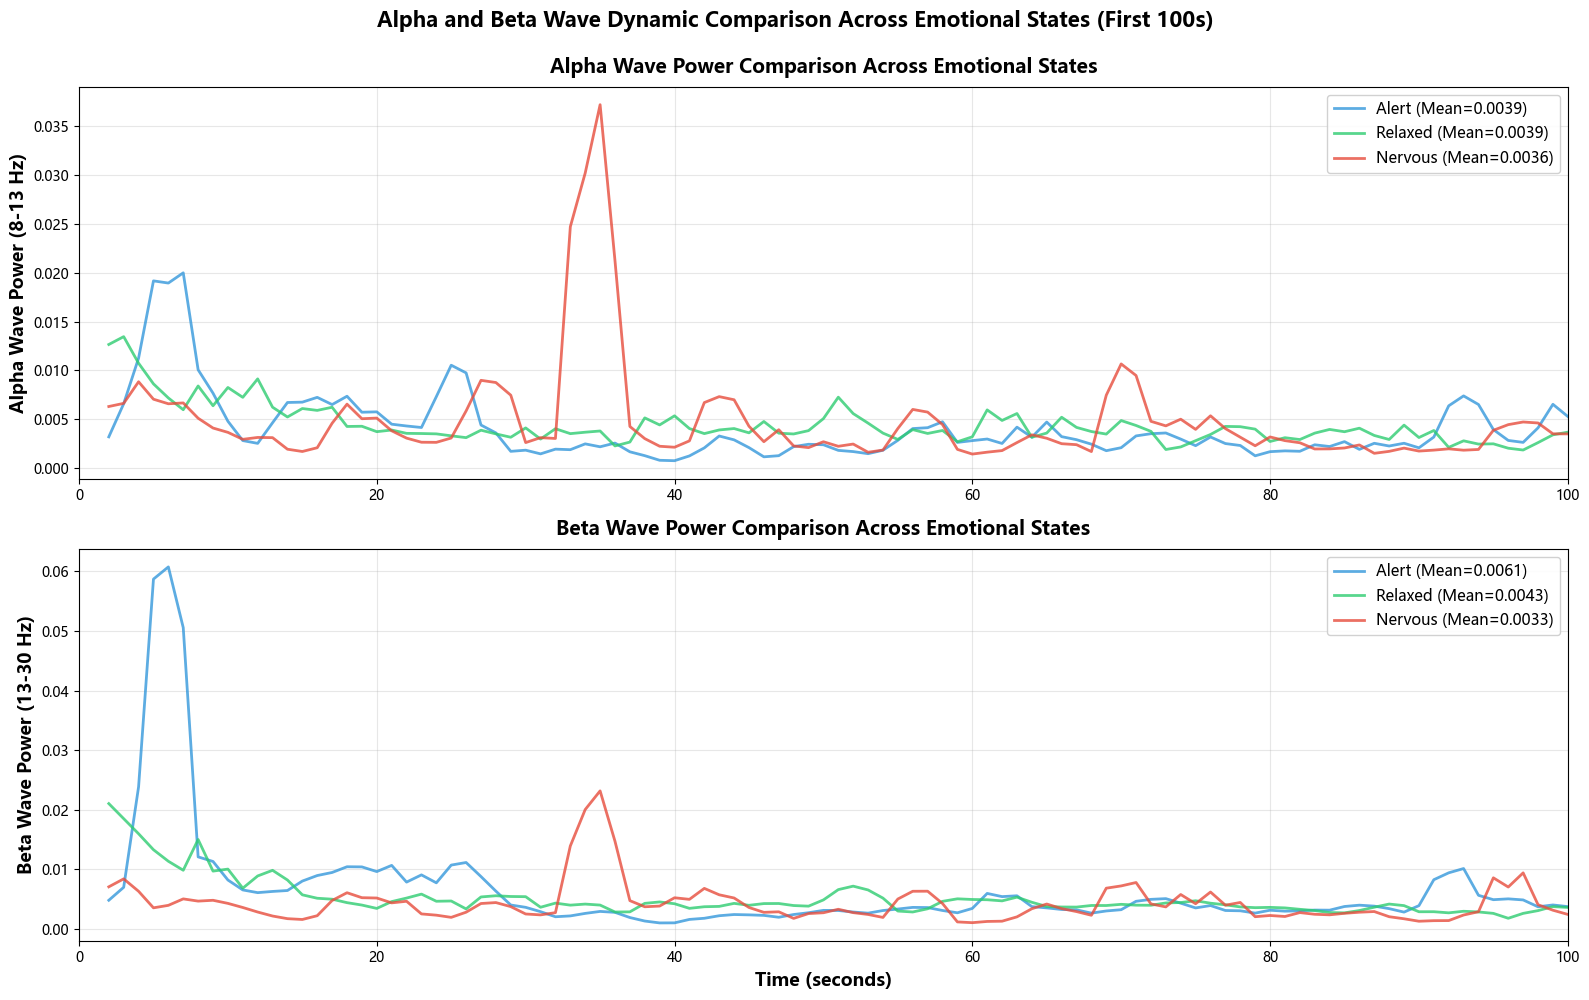


对比图说明:
  - 蓝色线：Alert（警觉/专注）状态
  - 绿色线：Relaxed（放松）状态
  - 红色线：Nervous（紧张）状态
  - 上图：α波（8-13Hz）随时间变化
  - 下图：β波（13-30Hz）随时间变化
  - 可以观察不同状态下α波和β波的动态差异


In [77]:
# ============================================================================
# 绘制三种情绪状态的α波和β波对比图
# ============================================================================

# ----------------------------------------------------------------------------
# 创建2行1列的子图布局
# ----------------------------------------------------------------------------
# 上图：三种状态的α波对比
# 下图：三种状态的β波对比
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# ----------------------------------------------------------------------------
# 定义三种情绪状态的颜色映射
# ----------------------------------------------------------------------------
# 使用不同颜色区分三种情绪状态，便于直观对比
# 注意：键名必须与all_results中的键名完全一致
colors = {
    'Alert': '#3498db',     # 蓝色 - 代表冷静、专注
    'Relaxed': '#2ecc71',   # 绿色 - 代表平和、放松
    'Nervous': '#e74c3c'    # 红色 - 代表紧张、激动
}

# ============================================================================
# 上图：三种状态的α波时间变化对比
# ============================================================================

# 遍历所有情绪状态，绘制α波曲线
for state_name, result in all_results.items():
    # ------------------------------------------------------------------------
    # 为了对比清晰，只显示前100秒的数据
    # ------------------------------------------------------------------------
    max_time = 100  # 时间上限（秒）
    
    # 提取α波数据
    time_alpha = result['time_alpha']
    power_alpha = result['power_alpha']
    
    # 创建时间掩码，筛选出前100秒的数据点
    mask = time_alpha <= max_time
    
    # 绘制该状态的α波曲线
    ax1.plot(
        time_alpha[mask],                            # X轴：时间（前100秒）
        power_alpha[mask],                           # Y轴：α波能量
        color=colors[state_name],                    # 使用预定义的颜色
        linewidth=2,                                 # 线条宽度
        label=f"{state_name} (Mean={result['alpha_mean']:.4f})",  # 图例标签（包含平均值）
        alpha=0.8                                    # 透明度80%
    )
   
# 设置上图的属性
ax1.set_ylabel('Alpha Wave Power (8-13 Hz)', fontsize=13, fontweight='bold')  # Y轴标签
ax1.set_title('Alpha Wave Power Comparison Across Emotional States', fontsize=14, fontweight='bold', pad=10)  # 标题
ax1.grid(True, alpha=0.3)  # 显示网格
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)  # 显示图例，framealpha设置图例背景透明度
ax1.set_xlim([0, max_time])  # 限制X轴范围：0-100秒

# ============================================================================
# 下图：三种状态的β波时间变化对比
# ============================================================================

# 遍历所有情绪状态，绘制β波曲线
for state_name, result in all_results.items():
    # 提取β波数据
    time_beta = result['time_beta']
    power_beta = result['power_beta']
    
    # 创建时间掩码，筛选出前100秒的数据点
    mask = time_beta <= max_time
    
    # 绘制该状态的β波曲线
    ax2.plot(
        time_beta[mask],                             # X轴：时间（前100秒）
        power_beta[mask],                            # Y轴：β波能量
        color=colors[state_name],                    # 使用预定义的颜色
        linewidth=2,                                 # 线条宽度
        label=f"{state_name} (Mean={result['beta_mean']:.4f})",  # 图例标签（包含平均值）
        alpha=0.8                                    # 透明度80%
    )

# 设置下图的属性
ax2.set_xlabel('Time (seconds)', fontsize=13, fontweight='bold')  # X轴标签
ax2.set_ylabel('Beta Wave Power (13-30 Hz)', fontsize=13, fontweight='bold')  # Y轴标签
ax2.set_title('Beta Wave Power Comparison Across Emotional States', fontsize=14, fontweight='bold', pad=10)  # 标题
ax2.grid(True, alpha=0.3)  # 显示网格
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)  # 显示图例
ax2.set_xlim([0, max_time])  # 限制X轴范围：0-100秒

# ----------------------------------------------------------------------------
# 设置整个图形的总标题
# ----------------------------------------------------------------------------
plt.suptitle(
    'Alpha and Beta Wave Dynamic Comparison Across Emotional States (First 100s)',  # 总标题
    fontsize=15,                                    # 字体大小
    fontweight='bold',                              # 粗体
    y=0.995                                         # Y位置（稍微向上移动避免与子图重叠）
)

# 自动调整布局
plt.tight_layout()

# 显示图形
plt.show()

# ----------------------------------------------------------------------------
# 打印对比图说明
# ----------------------------------------------------------------------------
print("\n对比图说明:")
print("  - 蓝色线：Alert（警觉/专注）状态")
print("  - 绿色线：Relaxed（放松）状态")
print("  - 红色线：Nervous（紧张）状态")
print("  - 上图：α波（8-13Hz）随时间变化")
print("  - 下图：β波（13-30Hz）随时间变化")
print("  - 可以观察不同状态下α波和β波的动态差异")

## 5. 观察与总结

### 5.1 α波和β波的定量对比

In [78]:
# ============================================================================
# 三种情绪状态的α波和β波统计对比分析
# ============================================================================

print("\n" + "="*70)
print("三种情绪状态的α波和β波统计对比")
print("="*70)

# ----------------------------------------------------------------------------
# 创建对比表格，显示所有状态的统计指标
# ----------------------------------------------------------------------------
print("\n状态                     α波平均      α波标准差    β波平均      β波标准差    α/β比率")
print("-" * 90)

# 遍历所有状态，按表格格式打印统计数据
for state_name, result in all_results.items():
    # 使用格式化字符串，对齐输出各项指标
    print(f"{state_name:20s}  "                      # 状态名称，左对齐20个字符
          f"{result['alpha_mean']:10.6f}  "          # α波平均值，10位宽度，6位小数
          f"{result['alpha_std']:10.6f}  "           # α波标准差，10位宽度，6位小数
          f"{result['beta_mean']:10.6f}  "           # β波平均值，10位宽度，6位小数
          f"{result['beta_std']:10.6f}  "            # β波标准差，10位宽度，6位小数
          f"{result['alpha_beta_ratio']:8.4f}")      # α/β比率，8位宽度，4位小数

# ============================================================================
# α波（8-13 Hz）分析
# ============================================================================
print("\n" + "="*70)
print("【α波（8-13 Hz）分析】")
print("="*70)

# 提取所有状态的α波平均值，创建字典
alpha_values = {state: result['alpha_mean'] for state, result in all_results.items()}

# 按α波能量从高到低排序
sorted_alpha = sorted(alpha_values.items(), key=lambda x: x[1], reverse=True)

# 打印α波能量排名
print("\nα波能量排名（从高到低）：")
for rank, (state, value) in enumerate(sorted_alpha, 1):
    # enumerate(sorted_alpha, 1)：从1开始编号
    print(f"  第{rank}名: {state:25s} - {value:.6f}")

# 计算最大值与最小值的相对差异（百分比）
max_alpha = sorted_alpha[0][1]   # 最高α波能量
min_alpha = sorted_alpha[-1][1]  # 最低α波能量
alpha_diff = ((max_alpha - min_alpha) / max_alpha) * 100  # 相对差异百分比

print(f"\n最大值与最小值差异: {alpha_diff:.1f}%")
print(f"结论: {sorted_alpha[0][0]} 状态的α波能量最高，可能处于相对放松/警觉平衡状态")

# ============================================================================
# β波（13-30 Hz）分析
# ============================================================================
print("\n" + "="*70)
print("【β波（13-30 Hz）分析】")
print("="*70)

# 提取所有状态的β波平均值，创建字典
beta_values = {state: result['beta_mean'] for state, result in all_results.items()}

# 按β波能量从高到低排序
sorted_beta = sorted(beta_values.items(), key=lambda x: x[1], reverse=True)

# 打印β波能量排名
print("\nβ波能量排名（从高到低）：")
for rank, (state, value) in enumerate(sorted_beta, 1):
    print(f"  第{rank}名: {state:25s} - {value:.6f}")

# 计算最大值与最小值的相对差异（百分比）
max_beta = sorted_beta[0][1]     # 最高β波能量
min_beta = sorted_beta[-1][1]    # 最低β波能量
beta_diff = ((max_beta - min_beta) / max_beta) * 100  # 相对差异百分比

print(f"\n最大值与最小值差异: {beta_diff:.1f}%")
print(f"结论: {sorted_beta[0][0]} 状态的β波能量最高，表明更高的警觉性/认知活动")

# ============================================================================
# α/β比率分析
# ============================================================================
print("\n" + "="*70)
print("【α/β比率分析】")
print("="*70)

# 提取所有状态的α/β比率，创建字典
ratio_values = {state: result['alpha_beta_ratio'] for state, result in all_results.items()}

# 按α/β比率从高到低排序
sorted_ratio = sorted(ratio_values.items(), key=lambda x: x[1], reverse=True)

# 打印α/β比率排名，并附上解释
print("\nα/β比率排名（从高到低）：")
for rank, (state, value) in enumerate(sorted_ratio, 1):
    # 根据比率值给出解释
    interpretation = ""
    if value > 1.5:
        interpretation = "（α波占优势，偏放松）"
    elif value < 0.7:
        interpretation = "（β波占优势，偏警觉/紧张）"
    else:
        interpretation = "（相对平衡）"
    
    print(f"  第{rank}名: {state:25s} - {value:.4f} {interpretation}")

# 打印α/β比率的解释说明
print(f"\n关键理解: ")
print(f"  - α/β比率 > 1.5: 放松状态（α波占主导）")
print(f"  - α/β比率 < 0.7: 警觉/紧张状态（β波占主导）")
print(f"  - α/β比率在0.7-1.5之间: 中性/平衡状态")
print("="*70)


三种情绪状态的α波和β波统计对比

状态                     α波平均      α波标准差    β波平均      β波标准差    α/β比率
------------------------------------------------------------------------------------------
Alert                   0.003927    0.003347    0.006084    0.009105    0.6454
Relaxed                 0.003882    0.001580    0.004261    0.002097    0.9111
Nervous                 0.003559    0.003579    0.003333    0.002518    1.0679

【α波（8-13 Hz）分析】

α波能量排名（从高到低）：
  第1名: Alert                     - 0.003927
  第2名: Relaxed                   - 0.003882
  第3名: Nervous                   - 0.003559

最大值与最小值差异: 9.4%
结论: Alert 状态的α波能量最高，可能处于相对放松/警觉平衡状态

【β波（13-30 Hz）分析】

β波能量排名（从高到低）：
  第1名: Alert                     - 0.006084
  第2名: Relaxed                   - 0.004261
  第3名: Nervous                   - 0.003333

最大值与最小值差异: 45.2%
结论: Alert 状态的β波能量最高，表明更高的警觉性/认知活动

【α/β比率分析】

α/β比率排名（从高到低）：
  第1名: Nervous                   - 1.0679 （相对平衡）
  第2名: Relaxed                   - 0.9111 （相对平衡）
  第3名: Alert               

### 5.2 观察总结：α波和β波与情绪状态的关系

print("="*70)
print("观察结论总结")
print("="*70)

print("""
根据α波和β波的时间变化分析，我们可以得出以下结论：

一、α波（8-13 Hz）- 放松指标

特征：
  • 与闭眼放松、安静清醒状态相关
  • α波增强 → 表示放松、平静
  • α波下降 → 表示紧张、焦虑或专注任务

观察要点：
  - 在时间序列图中，观察α波能量的整体水平和波动幅度
  - 较高且稳定的α波 → 持续放松状态
  - 较低且不稳定的α波 → 紧张或警觉状态

二、β波（13-30 Hz）- 警觉/紧张指标

特征：
  • 与警觉、专注、积极思考、紧张焦虑相关
  • β波升高 → 表示警觉、专注或紧张
  • β波下降 → 表示放松、压力减轻

观察要点：
  - 在时间序列图中，观察β波能量的动态变化
  - 持续较高的β波 → 高度警觉或持续紧张
  - 适中的β波 → 正常专注状态
  - 较低的β波 → 放松、休息状态

三、α/β比率 - 综合情绪指标

判断标准：
  • α/β > 1.5  → 放松状态占主导（α波优势）
  • α/β < 0.7  → 警觉/紧张状态占主导（β波优势）
  • 0.7 ≤ α/β ≤ 1.5 → 中性平衡状态

四、音乐干预的效果评估标准

预期的有效干预应该表现为：
  1. α波增强（5%以上）→ 表明放松效果
  2. β波下降（5%以上）→ 表明压力缓解
  3. α/β比率上升 → 表明整体情绪向放松方向转变

时间变化的意义：
  - 观察α波和β波随时间的动态变化
  - 评估音乐干预前后的波形差异
  - 判断干预效果是否持续稳定

五、深度学习模型如何利用这些特征

我们的EEGBiFormer模型：
  1. 自动提取16通道×时间窗口的原始EEG特征
  2. 隐式学习α波、β波等频段的能量分布模式
  3. 捕捉多频段之间的交互关系和时间动态
  4. 基于学到的模式进行情绪状态分类

模型优势：
  • 不依赖人工定义的频段边界
  • 自动学习最优的特征组合
  • 适应个体差异和场景变化
  • 端到端训练，性能更优

本实验的教学价值：
  ✓ 理解α波和β波与情绪状态的基本关系
  ✓ 学会观察和分析EEG时间序列数据
  ✓ 掌握评估音乐干预效果的量化指标
  ✓ 为深度学习模型的可解释性提供基础
  ✓ 培养科学分析和数据可视化能力
""")


---

## 6. 下一步：应用到音乐干预实验

### 6.1 如何使用本分析方法评估音乐干预效果

**实验流程：**

1. **采集干预前数据** → 记录被试在正常/紧张状态下的EEG
2. **施加音乐干预** → 播放舒缓音乐15-30分钟
3. **采集干预后数据** → 继续记录EEG数据
4. **对比分析** → 使用本notebook的方法分析α波和β波变化

**评估标准：**
- α波增强 > 5% → 放松效果显著
- β波下降 > 5% → 压力缓解效果显著
- α/β比率提高 → 整体情绪向放松方向转变

**使用配套脚本：**

你可以使用项目中的 `EEG_wave_change_analysis.py` 脚本快速分析单个或对比两个EEG文件：

```python
# 分析单个文件
python EEG_wave_change_analysis.py

# 修改脚本中的文件路径即可使用对比功能
```

---

### 6.2 课后作业

**基础作业：**
1. 修改 `WINDOW_SIZE` 参数（2秒、6秒），观察时间序列曲线的变化
2. 尝试分析单个通道（如 `CHANNELS = 0`），对比与所有通道平均的差异
3. 观察图表中α波和β波的动态变化，写出你的发现

**进阶作业：**
1. 采集自己的EEG数据（放松状态和紧张状态各5分钟）
2. 使用本notebook分析你自己的数据
3. 尝试施加音乐干预，对比干预前后的α波和β波变化
4. 整理实验报告，包括：频谱图、波形对比图、个人结论

---

**教学重点回顾**

通过本模块，我们学习了：
1. ✅ 加载和预处理16通道EEG数据（滤波 + 标准化）
2. ✅ 使用滑动窗口计算α波和β波的时间序列
3. ✅ 绘制和解读α波、β波随时间变化的曲线
4. ✅ 对比三种情绪状态的α波和β波特征差异
5. ✅ 理解α/β比率作为情绪指标的意义
6. ✅ 掌握评估音乐干预效果的量化方法


---
